# Analyse HSIC-ANOVA hiérarchique sur sorties MAELIA réelles

Ce notebook applique la méthode HSIC-ANOVA hiérarchique aux sorties réellement produites par MAELIA.

La logique est la suivante :

- normalisation des variables continues ;
- apprentissage d'une Random Forest par sortie ;
- importance par permutation pour construire les échelles de noyaux `theta` ;
- appel à `hsic_anova_hierarchical` avec les variables actives/inactives du plan hiérarchique.

Note pratique : HSIC construit des matrices de distance en `n × n`. Pour éviter une explosion mémoire sur 10 000 simulations, le notebook contient un paramètre `HSIC_MAX_SAMPLES`.

## 1. Imports, chemins et paramètres

In [46]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('/Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA')
ANALYSIS_DIR = PROJECT_ROOT / 'analysis'
TOOLS_DIR = ANALYSIS_DIR / 'tools'
OUTPUT_DIR = ANALYSIS_DIR / 'hsic_anova_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

from hsic_methods import hsic_anova_hierarchical

OUTPUT_COLS = ['N_lixi', 'dCorg', 'rdt']
DATASET_FILENAME = 'dataset_metamodel.csv'
DATASET_CANDIDATES = [
    PROJECT_ROOT / 'simulations' / 'log_terrainSA',
    PROJECT_ROOT / 'data' / DATASET_FILENAME,
    ANALYSIS_DIR / DATASET_FILENAME,
]

RANDOM_SEED = 42
RF_N_ESTIMATORS = 200
RF_MAX_DEPTH = 10
RF_MIN_SAMPLES_LEAF = 15
PERMUTATION_REPEATS = 10
THETA_SCALE = 5.0
THETA_IMPORTANCE_THRESHOLD = 0.005
HSIC_MAX_ORDER = 4

# Mettre None pour utiliser tous les points. Attention : coût mémoire en O(n² × p).
HSIC_MAX_SAMPLES = 1500

print(f'Projet : {PROJECT_ROOT}')
print(f'Outils HSIC : {TOOLS_DIR}')
print(f'Sorties : {OUTPUT_DIR}')


Projet : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA
Outils HSIC : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/tools
Sorties : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results


## 2. Chargement du dataset réel MAELIA

In [47]:
def resolve_dataset_path(candidates, filename=DATASET_FILENAME):
    checked = []
    for candidate in candidates:
        candidate = Path(candidate).expanduser()
        checked.append(candidate)

        if candidate.is_file():
            return candidate, checked

        if candidate.is_dir():
            direct_csv = candidate / filename
            checked.append(direct_csv)
            if direct_csv.is_file():
                return direct_csv, checked

            nested = sorted(candidate.rglob(filename))
            checked.extend(nested[:5])
            if nested:
                return nested[0], checked

    return None, checked


DATASET_PATH, checked_dataset_paths = resolve_dataset_path(DATASET_CANDIDATES)

if DATASET_PATH is None:
    print('Aucun dataset terrainSA trouvé. Chemins testés :')
    for candidate in checked_dataset_paths:
        print(' -', candidate)
    raise FileNotFoundError(
        'Exécuter le notebook de simulation terrainSA jusqu’à export de dataset_metamodel.csv, '
        'ou renseigner DATASET_CANDIDATES avec le dossier contenant ce fichier.'
    )

df_raw = pd.read_csv(DATASET_PATH)
print('Dataset chargé :', DATASET_PATH)
print('Dimensions :', df_raw.shape)
display(df_raw.head())

EXPECTED_N_FEATURES = 15
feat_cols = [f'feat_{i}' for i in range(EXPECTED_N_FEATURES)]
missing_features = [col for col in feat_cols if col not in df_raw.columns]
missing_outputs = [col for col in OUTPUT_COLS if col not in df_raw.columns]

if missing_features:
    raise ValueError(
        'Le dataset doit contenir les colonnes feat_* du plan SMT courant. '
        f'Colonnes manquantes : {missing_features}'
    )
if missing_outputs:
    raise ValueError(f'Sorties MAELIA absentes du dataset : {missing_outputs}')


Dataset chargé : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/simulations/log_terrainSA/dataset_metamodel.csv
Dimensions : (9900, 22)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_12,feat_13,feat_14,Milieu (Climat),Milieu (Sol),N_lixi,dCorg,rdt,point_idx,parcelle
0,3.0,1.0,0.0,85.320657,-18.764150,1.696037,2.910397,13.0,201.780979,267.420940,...,66.561746,85.561749,50.671302,0,0,5.004,-183.912,8.985,100,beauce_5_sa_000
1,2.0,1.0,0.0,64.405745,-31.838558,2.285810,9.402525,13.0,228.211825,234.148132,...,79.017908,63.277857,55.000000,0,0,4.044,-184.702,9.000,101,beauce_5_sa_001
2,1.0,0.0,0.0,81.546150,-24.000000,2.384159,13.000000,13.0,141.170110,266.500000,...,61.709324,55.000000,55.000000,0,0,4.830,-238.432,8.395,102,beauce_5_sa_002
3,2.0,0.0,0.0,57.958942,-24.000000,3.441391,13.000000,13.0,292.637532,303.972335,...,26.286161,97.956788,55.000000,0,0,7.816,-234.862,8.240,103,beauce_5_sa_003
4,2.0,0.0,0.0,98.641403,-24.000000,2.334536,13.000000,13.0,295.368350,286.795490,...,93.908180,11.450603,55.000000,0,0,7.184,-140.132,7.890,104,beauce_5_sa_004


## 3. Reconstruction des 15 paramètres agricoles

In [48]:
AGRI_FEATURES = ['n_ferti', 'has_prepa', 'nb_prepa', 'Date_Semis', 'Delta_PREPA_Semis', 'Profondeur_Semis', 'Profondeur_Prepa_1', 'Profondeur_Prepa_2', 'Date_F1', 'Date_F2', 'Date_F3', 'Date_Recolte', 'Dose_F1', 'Dose_F2', 'Dose_F3']

AGRI_CATEGORICAL = ['n_ferti', 'has_prepa', 'nb_prepa']
AGRI_CONTINUOUS = [feature for feature in AGRI_FEATURES if feature not in AGRI_CATEGORICAL]

feat_cols = [f'feat_{i}' for i in range(len(AGRI_FEATURES))]
X_params = df_raw[feat_cols].copy()
X_params.columns = AGRI_FEATURES
for col in AGRI_FEATURES:
    X_params[col] = pd.to_numeric(X_params[col], errors='coerce')

Y_outputs = df_raw[OUTPUT_COLS].copy()
for col in OUTPUT_COLS:
    Y_outputs[col] = pd.to_numeric(Y_outputs[col], errors='coerce')

df = pd.concat([X_params, Y_outputs], axis=1).dropna(subset=OUTPUT_COLS).reset_index(drop=True)
print('Nombre de lignes exploitables :', len(df))
print('Paramètres agricoles :', len(AGRI_FEATURES))
print('Sorties :', OUTPUT_COLS)
display(df[AGRI_FEATURES + OUTPUT_COLS].head())


Nombre de lignes exploitables : 9900
Paramètres agricoles : 15
Sorties : ['N_lixi', 'dCorg', 'rdt']


,n_ferti,has_prepa,nb_prepa,Date_Semis,Delta_PREPA_Semis,Profondeur_Semis,Profondeur_Prepa_1,Profondeur_Prepa_2,Date_F1,Date_F2,Date_F3,Date_Recolte,Dose_F1,Dose_F2,Dose_F3,N_lixi,dCorg,rdt
0,3.0,1.0,0.0,85.320657,-18.764150,1.696037,2.910397,13.0,201.780979,267.420940,304.970634,368.508819,66.561746,85.561749,50.671302,5.004,-183.912,8.985
1,2.0,1.0,0.0,64.405745,-31.838558,2.285810,9.402525,13.0,228.211825,234.148132,281.500000,375.778807,79.017908,63.277857,55.000000,4.044,-184.702,9.000
2,1.0,0.0,0.0,81.546150,-24.000000,2.384159,13.000000,13.0,141.170110,266.500000,281.500000,370.348657,61.709324,55.000000,55.000000,4.830,-238.432,8.395
3,2.0,0.0,0.0,57.958942,-24.000000,3.441391,13.000000,13.0,292.637532,303.972335,281.500000,379.382175,26.286161,97.956788,55.000000,7.816,-234.862,8.240
4,2.0,0.0,0.0,98.641403,-24.000000,2.334536,13.000000,13.0,295.368350,286.795490,281.500000,334.177678,93.908180,11.450603,55.000000,7.184,-140.132,7.890


## 4. Variables actives/inactives du plan hiérarchique

La méthode HSIC doit savoir si une variable est active pour chaque simulation. Ici, cette information est reconstruite depuis la logique du plan SMT réellement utilisé : par exemple `Date_F2` et `Dose_F2` ne sont actives que si `n_ferti >= 2`, et `Profondeur_Prepa_2` n'est active que lorsqu'une préparation du sol avec deux opérations est décrétée.

In [49]:
FEATURE_INDEX = {name: i for i, name in enumerate(AGRI_FEATURES)}

CONDITIONALLY_ACTING = ['nb_prepa', 'Delta_PREPA_Semis', 'Profondeur_Prepa_1', 'Profondeur_Prepa_2', 'Date_F1', 'Dose_F1', 'Date_F2', 'Dose_F2', 'Date_F3', 'Dose_F3']

num_is_decreed = np.array([feature in CONDITIONALLY_ACTING for feature in AGRI_FEATURES], dtype=bool)
is_categorical = np.array([feature in AGRI_CATEGORICAL for feature in AGRI_FEATURES], dtype=bool)


def build_acting_matrix(X_df):
    acting = np.ones((len(X_df), len(AGRI_FEATURES)), dtype=bool)

    n_ferti = X_df['n_ferti'].to_numpy()
    has_prepa = X_df['has_prepa'].to_numpy() == 1
    nb_prepa = X_df['nb_prepa'].to_numpy()

    def set_active(feature, mask):
        acting[:, FEATURE_INDEX[feature]] = mask

    for feature in ['nb_prepa', 'Delta_PREPA_Semis', 'Profondeur_Prepa_1']:
        set_active(feature, has_prepa)
    set_active('Profondeur_Prepa_2', has_prepa & (nb_prepa == 1))

    for feature in ['Date_F1', 'Dose_F1']:
        set_active(feature, n_ferti >= 1)
    for feature in ['Date_F2', 'Dose_F2']:
        set_active(feature, n_ferti >= 2)
    for feature in ['Date_F3', 'Dose_F3']:
        set_active(feature, n_ferti >= 3)

    return acting


x_is_acting_full = build_acting_matrix(df[AGRI_FEATURES])
acting_summary = pd.DataFrame({
    'variable': AGRI_FEATURES,
    'conditionnelle': num_is_decreed,
    'categorielle': is_categorical,
    'frequence_active': x_is_acting_full.mean(axis=0),
})
display(acting_summary)
acting_summary.to_csv(OUTPUT_DIR / 'hsic_variable_acting_summary.csv', index=False)


,variable,conditionnelle,categorielle,frequence_active
0,n_ferti,False,True,1.000000
1,has_prepa,False,True,1.000000
2,nb_prepa,True,True,0.497374
3,Date_Semis,False,False,1.000000
4,Delta_PREPA_Semis,True,False,0.497374
5,Profondeur_Semis,False,False,1.000000
6,Profondeur_Prepa_1,True,False,0.497374
7,Profondeur_Prepa_2,True,False,0.250606
8,Date_F1,True,False,0.746364
9,Date_F2,True,False,0.501818


## 5. Normalisation numérique

Les variables continues sont ramenées dans `[0, 1]` sur les bornes observées dans le dataset réel. Les variables catégorielles restent sous leur codage entier, car `hsic_methods.py` leur applique une distance d'égalité/différence.

In [50]:
X_numeric_full = df[AGRI_FEATURES].copy()

for col in AGRI_FEATURES:
    X_numeric_full[col] = pd.to_numeric(X_numeric_full[col], errors='coerce')

for col in AGRI_CATEGORICAL:
    X_numeric_full[col] = X_numeric_full[col].fillna(0).round().astype(float)

# Pour les catégorielles conditionnelles, on force une modalité inactive dédiée.
# Sinon une variable inactive codée 0 pourrait être confondue avec une vraie modalité active 0.
for col in AGRI_CATEGORICAL:
    idx = FEATURE_INDEX[col]
    if num_is_decreed[idx]:
        X_numeric_full.loc[~x_is_acting_full[:, idx], col] = -1.0

for col in AGRI_CONTINUOUS:
    values = X_numeric_full[col].astype(float)
    fill_value = values.median()
    values = values.fillna(fill_value)
    vmin = values.min()
    vmax = values.max()
    if np.isfinite(vmin) and np.isfinite(vmax) and vmax > vmin:
        X_numeric_full[col] = (values - vmin) / (vmax - vmin)
    else:
        X_numeric_full[col] = 0.0

X_numeric_full = X_numeric_full.to_numpy(dtype=float)
print('Matrice X normalisée :', X_numeric_full.shape)


Matrice X normalisée : (9900, 15)


## 6. Sous-échantillon HSIC reproductible

La Random Forest est entraînée sur toutes les lignes disponibles. Le calcul HSIC peut ensuite être réalisé sur un sous-échantillon reproductible pour rester compatible avec la mémoire disponible.

In [51]:
rng = np.random.default_rng(RANDOM_SEED)
n_total = len(df)

if HSIC_MAX_SAMPLES is None or HSIC_MAX_SAMPLES >= n_total:
    hsic_idx = np.arange(n_total)
else:
    hsic_idx = np.sort(rng.choice(n_total, size=HSIC_MAX_SAMPLES, replace=False))

X_hsic = X_numeric_full[hsic_idx]
x_is_acting_hsic = x_is_acting_full[hsic_idx]

print(f'Points disponibles : {n_total}')
print(f'Points utilisés pour HSIC : {len(hsic_idx)}')
pd.Series(hsic_idx, name='row_index').to_csv(OUTPUT_DIR / 'hsic_sample_indices.csv', index=False)


Points disponibles : 9900
Points utilisés pour HSIC : 1500


## 7. Random Forest supervisée et HSIC-ANOVA par sortie

In [52]:
all_importance_tables = []
all_hsic_tables = []
summary_rows = []

for output in OUTPUT_COLS:
    print()
    print('=' * 90)
    print(f'Sortie MAELIA : {output}')
    print('=' * 90)

    y_full = df[output].to_numpy(dtype=float)
    y_hsic = y_full[hsic_idx]

    rf = RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    rf.fit(X_numeric_full, y_full)

    result = permutation_importance(
        rf,
        X_numeric_full,
        y_full,
        n_repeats=PERMUTATION_REPEATS,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    theta = result.importances_mean * THETA_SCALE
    theta[result.importances_mean < THETA_IMPORTANCE_THRESHOLD] = 0.0

    importance_df = pd.DataFrame({
        'sortie': output,
        'variable': AGRI_FEATURES,
        'importance_moyenne': result.importances_mean,
        'importance_ecart_type': result.importances_std,
        'theta': theta,
        'conditionnelle': num_is_decreed,
        'categorielle': is_categorical,
        'frequence_active': x_is_acting_full.mean(axis=0),
    }).sort_values('importance_moyenne', ascending=False)
    all_importance_tables.append(importance_df)
    display(importance_df.head(12))

    filtered_results, global_hsic = hsic_anova_hierarchical(
        X=X_hsic,
        Y=y_hsic,
        x_is_acting=x_is_acting_hsic,
        num_is_decreed=num_is_decreed,
        is_categorical=is_categorical,
        theta_scales=theta,
        var_names=AGRI_FEATURES,
        max_order=HSIC_MAX_ORDER,
        use_smt_theta=True,
        use_kta=False,
    )

    hsic_df = pd.DataFrame(filtered_results)
    if not hsic_df.empty:
        hsic_df['sortie'] = output
        hsic_df['variables'] = hsic_df['combo'].apply(
            lambda combo: ' & '.join(AGRI_FEATURES[i] for i in combo)
        )
        hsic_df['global_var_pct'] = 100 * hsic_df['trace'] / global_hsic if global_hsic != 0 else np.nan
        adj_sum = hsic_df['adj_trace'].sum()
        hsic_df['intrinsic_var_pct'] = 100 * hsic_df['adj_trace'] / adj_sum if adj_sum != 0 else np.nan
        hsic_df = hsic_df[
            ['sortie', 'order', 'variables', 'global_var_pct', 'intrinsic_var_pct', 'p_A', 'trace', 'adj_trace']
        ]
    else:
        hsic_df = pd.DataFrame(columns=[
            'sortie', 'order', 'variables', 'global_var_pct', 'intrinsic_var_pct', 'p_A', 'trace', 'adj_trace'
        ])

    all_hsic_tables.append(hsic_df)
    display(hsic_df.head(20))

    summary_rows.append({
        'sortie': output,
        'n_total': n_total,
        'n_hsic': len(hsic_idx),
        'global_hsic': global_hsic,
        'n_terms_kept': len(hsic_df),
        'rf_importance_sum': float(np.nansum(result.importances_mean)),
        'theta_non_zero': int(np.sum(theta > 0)),
    })

importance_all = pd.concat(all_importance_tables, ignore_index=True)
hsic_all = pd.concat(all_hsic_tables, ignore_index=True)
hsic_summary = pd.DataFrame(summary_rows)

importance_all.to_csv(OUTPUT_DIR / 'rf_permutation_importance_real_maelia.csv', index=False)
hsic_all.to_csv(OUTPUT_DIR / 'hsic_anova_terms_real_maelia.csv', index=False)
hsic_summary.to_csv(OUTPUT_DIR / 'hsic_anova_summary_real_maelia.csv', index=False)

print()
print('Fichiers écrits :')
print(' -', OUTPUT_DIR / 'rf_permutation_importance_real_maelia.csv')
print(' -', OUTPUT_DIR / 'hsic_anova_terms_real_maelia.csv')
print(' -', OUTPUT_DIR / 'hsic_anova_summary_real_maelia.csv')



Sortie MAELIA : N_lixi


,sortie,variable,importance_moyenne,importance_ecart_type,theta,conditionnelle,categorielle,frequence_active
0,N_lixi,n_ferti,0.567782,0.002976,2.838911,False,True,1.000000
8,N_lixi,Date_F1,0.364363,0.005395,1.821813,True,False,0.746364
13,N_lixi,Dose_F2,0.183638,0.003385,0.918191,True,False,0.501818
12,N_lixi,Dose_F1,0.168657,0.002670,0.843287,True,False,0.746364
14,N_lixi,Dose_F3,0.086265,0.001465,0.431325,True,False,0.254646
9,N_lixi,Date_F2,0.070585,0.001657,0.352926,True,False,0.501818
3,N_lixi,Date_Semis,0.037342,0.000460,0.186709,False,False,1.000000
11,N_lixi,Date_Recolte,0.005708,0.000100,0.028538,False,False,1.000000
4,N_lixi,Delta_PREPA_Semis,0.003092,0.000135,0.000000,True,False,0.497374
10,N_lixi,Date_F3,0.000911,0.000047,0.000000,True,False,0.254646


    Using provided RF theta scales.
    Evaluating combinations...

                      MAELIA SENSITIVITY ANALYSIS (HSIC-ANOVA)
Global HSIC (Total Dependency): 1.467104e-01

Order  | Global Var % | Intrinsic Var % | Act. Freq | Interacting Variables
-----------------------------------------------------------------------------------------------
  1    |      5.49%    |      22.00%    |    24.1%   | Dose_F3
  1    |     15.59%    |      14.70%    |    49.6%   | Dose_F2
  2    |      2.20%    |       8.81%    |    24.1%   | n_ferti & Dose_F3
  1    |      7.47%    |       7.04%    |    49.6%   | Date_F2
  1    |     19.77%    |       4.58%    |   100.0%   | n_ferti
  1    |     10.33%    |       4.28%    |    74.8%   | Date_F1
  1    |      8.91%    |       3.69%    |    74.8%   | Dose_F1
  3    |      0.91%    |       3.63%    |    24.1%   | n_ferti & Dose_F2 & Dose_F3
  2    |      4.66%    |       1.93%    |    74.8%   | n_ferti & Date_F1
  2    |      0.47%    |       1.87%    |   

,sortie,order,variables,global_var_pct,intrinsic_var_pct,p_A,trace,adj_trace
0,N_lixi,1,Dose_F3,5.494116,23.096117,0.240667,0.008060,0.139164
1,N_lixi,1,Dose_F2,15.587474,15.427142,0.496000,0.022868,0.092955
2,N_lixi,2,n_ferti & Dose_F3,2.200749,9.251491,0.240667,0.003229,0.055744
3,N_lixi,1,Date_F2,7.467597,7.390785,0.496000,0.010956,0.044533
4,N_lixi,1,n_ferti,19.767409,4.813077,1.000000,0.029001,0.029001
5,N_lixi,1,Date_F1,10.333352,4.496878,0.748000,0.015160,0.027096
6,N_lixi,1,Dose_F1,8.908206,3.876682,0.748000,0.013069,0.023359
7,N_lixi,3,n_ferti & Dose_F2 & Dose_F3,0.907299,3.814097,0.240667,0.001331,0.022982
8,N_lixi,2,n_ferti & Date_F1,4.664974,2.030108,0.748000,0.006844,0.012232
9,N_lixi,2,Dose_F2 & Dose_F3,0.465887,1.958491,0.240667,0.000684,0.011801



Sortie MAELIA : dCorg


...


Sortie MAELIA : rdt


,sortie,variable,importance_moyenne,importance_ecart_type,theta,conditionnelle,categorielle,frequence_active
0,rdt,n_ferti,1.999540,0.020934,9.997701,False,True,1.000000
12,rdt,Dose_F1,0.141305,0.003140,0.706524,True,False,0.746364
8,rdt,Date_F1,0.077314,0.001134,0.386572,True,False,0.746364
11,rdt,Date_Recolte,0.027752,0.000595,0.138758,False,False,1.000000
13,rdt,Dose_F2,0.015996,0.000375,0.079978,True,False,0.501818
3,rdt,Date_Semis,0.010899,0.000325,0.054495,False,False,1.000000
9,rdt,Date_F2,0.004851,0.000226,0.000000,True,False,0.501818
4,rdt,Delta_PREPA_Semis,0.004235,0.000097,0.000000,True,False,0.497374
14,rdt,Dose_F3,0.001993,0.000068,0.000000,True,False,0.254646
5,rdt,Profondeur_Semis,0.001516,0.000065,0.000000,False,False,1.000000


    Using provided RF theta scales.
    Evaluating combinations...

                      MAELIA SENSITIVITY ANALYSIS (HSIC-ANOVA)
Global HSIC (Total Dependency): 1.848255e-01

Order  | Global Var % | Intrinsic Var % | Act. Freq | Interacting Variables
-----------------------------------------------------------------------------------------------
  1    |     23.67%    |      26.89%    |    74.8%   | Dose_F1
  1    |     40.06%    |      25.46%    |   100.0%   | n_ferti
  1    |     14.24%    |      16.18%    |    74.8%   | Date_F1
  2    |      7.48%    |       8.49%    |    74.8%   | n_ferti & Dose_F1
  1    |      2.82%    |       7.28%    |    49.6%   | Dose_F2
  2    |      4.58%    |       5.21%    |    74.8%   | n_ferti & Date_F1
  3    |      2.78%    |       3.16%    |    74.8%   | n_ferti & Date_F1 & Dose_F1
  2    |      2.65%    |       3.01%    |    74.8%   | Date_F1 & Dose_F1
-----------------------------------------------------------------------------------------------
T

,sortie,order,variables,global_var_pct,intrinsic_var_pct,p_A,trace,adj_trace
0,rdt,1,Dose_F1,23.665294,28.098138,0.748,0.043739,0.078175
1,rdt,1,n_ferti,40.057987,26.610803,1.000,0.074037,0.074037
2,rdt,1,Date_F1,14.243409,16.911401,0.748,0.026325,0.047051
3,rdt,2,n_ferti & Dose_F1,7.476787,8.877295,0.748,0.013819,0.024699
4,rdt,1,Dose_F2,2.818686,7.611184,0.496,0.005210,0.021176
5,rdt,2,n_ferti & Date_F1,4.584639,5.443407,0.748,0.008474,0.015145
6,rdt,3,n_ferti & Date_F1 & Dose_F1,2.778807,3.299317,0.748,0.005136,0.009179
7,rdt,2,Date_F1 & Dose_F1,2.651746,3.148455,0.748,0.004901,0.008760



Fichiers écrits :
 - /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/rf_permutation_importance_real_maelia.csv
 - /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_terms_real_maelia.csv
 - /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_summary_real_maelia.csv


## 8. Résumé global

In [53]:
display(hsic_summary)

top_terms = (
    hsic_all.sort_values(['sortie', 'intrinsic_var_pct'], ascending=[True, False])
    .groupby('sortie')
    .head(12)
)
display(top_terms)


,sortie,n_total,n_hsic,global_hsic,n_terms_kept,rf_importance_sum,theta_non_zero
0,N_lixi,9900,1500,0.146710,34,1.490399,8
1,dCorg,9900,1500,0.054227,27,1.773523,10
2,rdt,9900,1500,0.184826,8,2.285739,6


,sortie,order,variables,global_var_pct,intrinsic_var_pct,p_A,trace,adj_trace
0,N_lixi,1,Dose_F3,5.494116,23.096117,0.240667,0.008060,0.139164
1,N_lixi,1,Dose_F2,15.587474,15.427142,0.496000,0.022868,0.092955
2,N_lixi,2,n_ferti & Dose_F3,2.200749,9.251491,0.240667,0.003229,0.055744
3,N_lixi,1,Date_F2,7.467597,7.390785,0.496000,0.010956,0.044533
4,N_lixi,1,n_ferti,19.767409,4.813077,1.000000,0.029001,0.029001
5,N_lixi,1,Date_F1,10.333352,4.496878,0.748000,0.015160,0.027096
6,N_lixi,1,Dose_F1,8.908206,3.876682,0.748000,0.013069,0.023359
7,N_lixi,3,n_ferti & Dose_F2 & Dose_F3,0.907299,3.814097,0.240667,0.001331,0.022982
8,N_lixi,2,n_ferti & Date_F1,4.664974,2.030108,0.748000,0.006844,0.012232
9,N_lixi,2,Dose_F2 & Dose_F3,0.465887,1.958491,0.240667,0.000684,0.011801


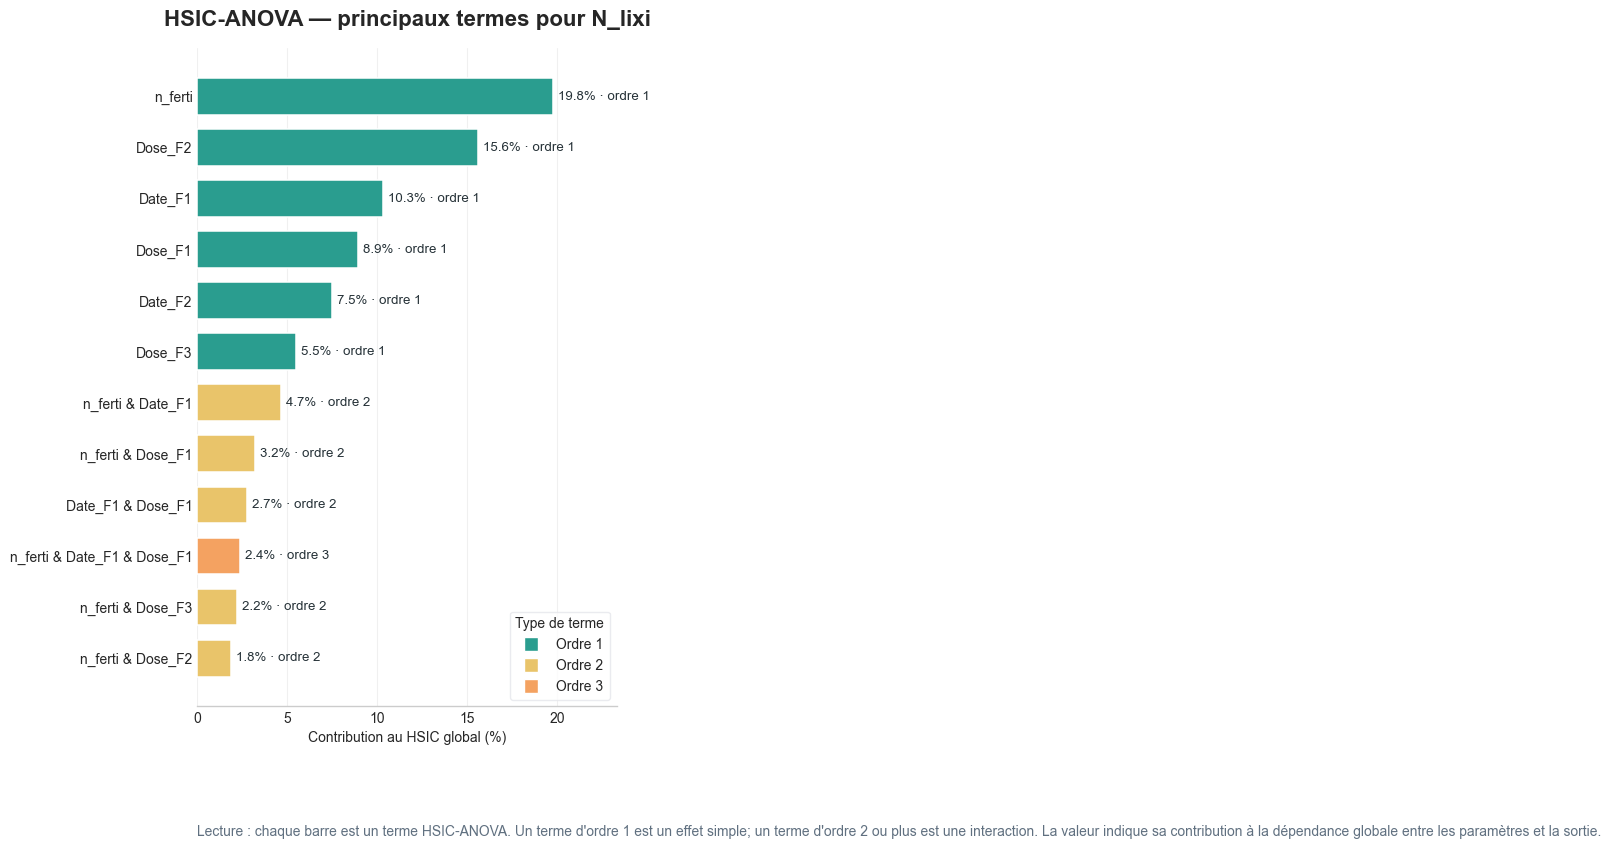

Figure sauvegardée : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_decomposition/hsic_anova_top_terms_N_lixi.png
Table sauvegardée : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_decomposition/hsic_anova_top_terms_N_lixi.csv


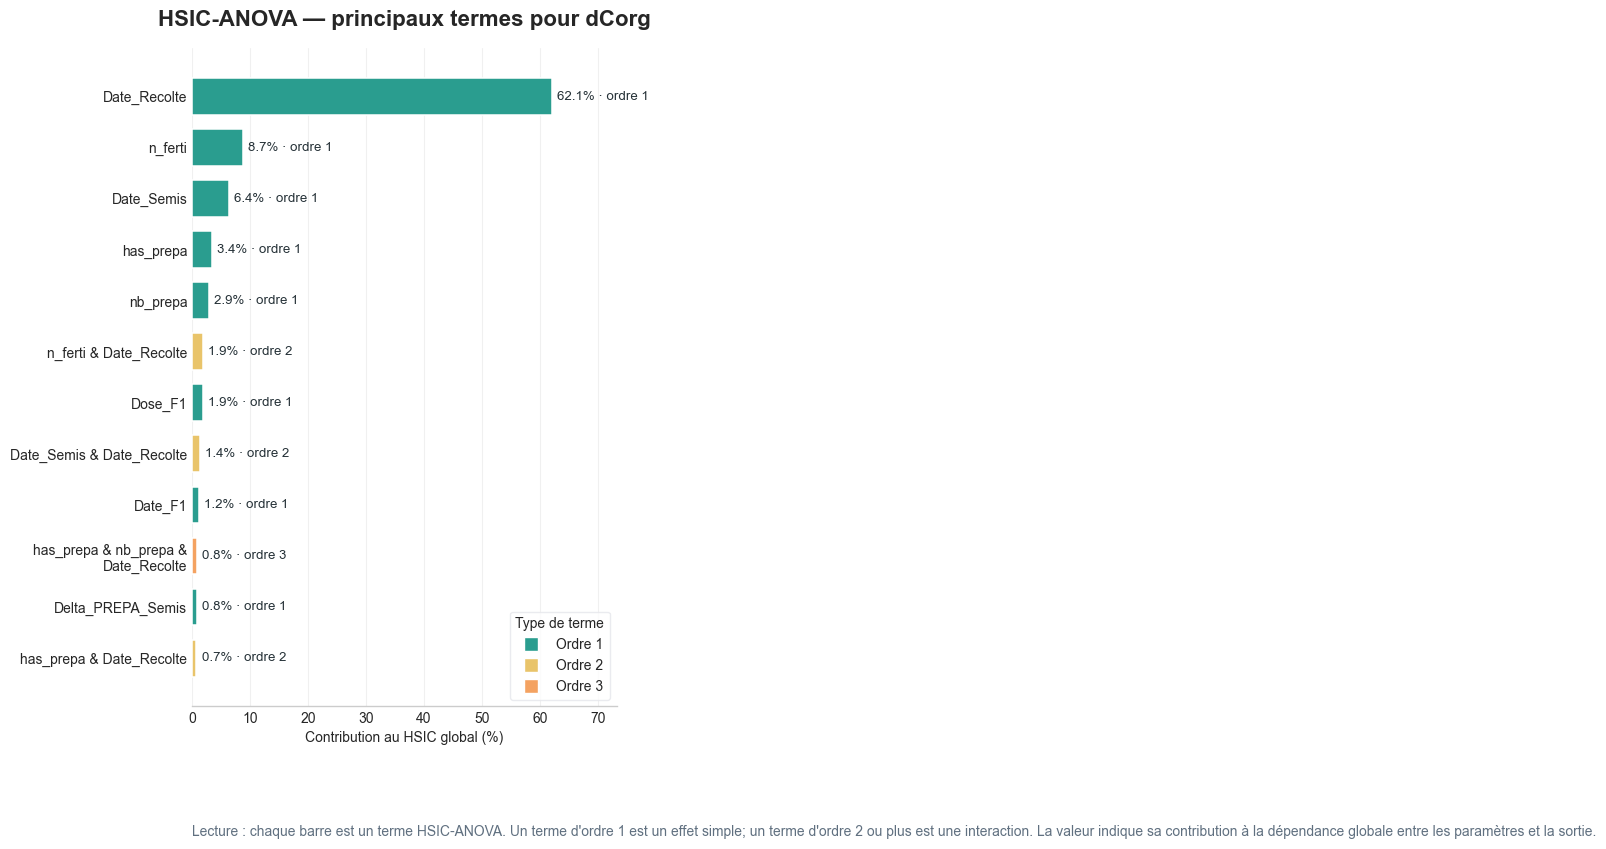

Figure sauvegardée : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_decomposition/hsic_anova_top_terms_dCorg.png
Table sauvegardée : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_decomposition/hsic_anova_top_terms_dCorg.csv


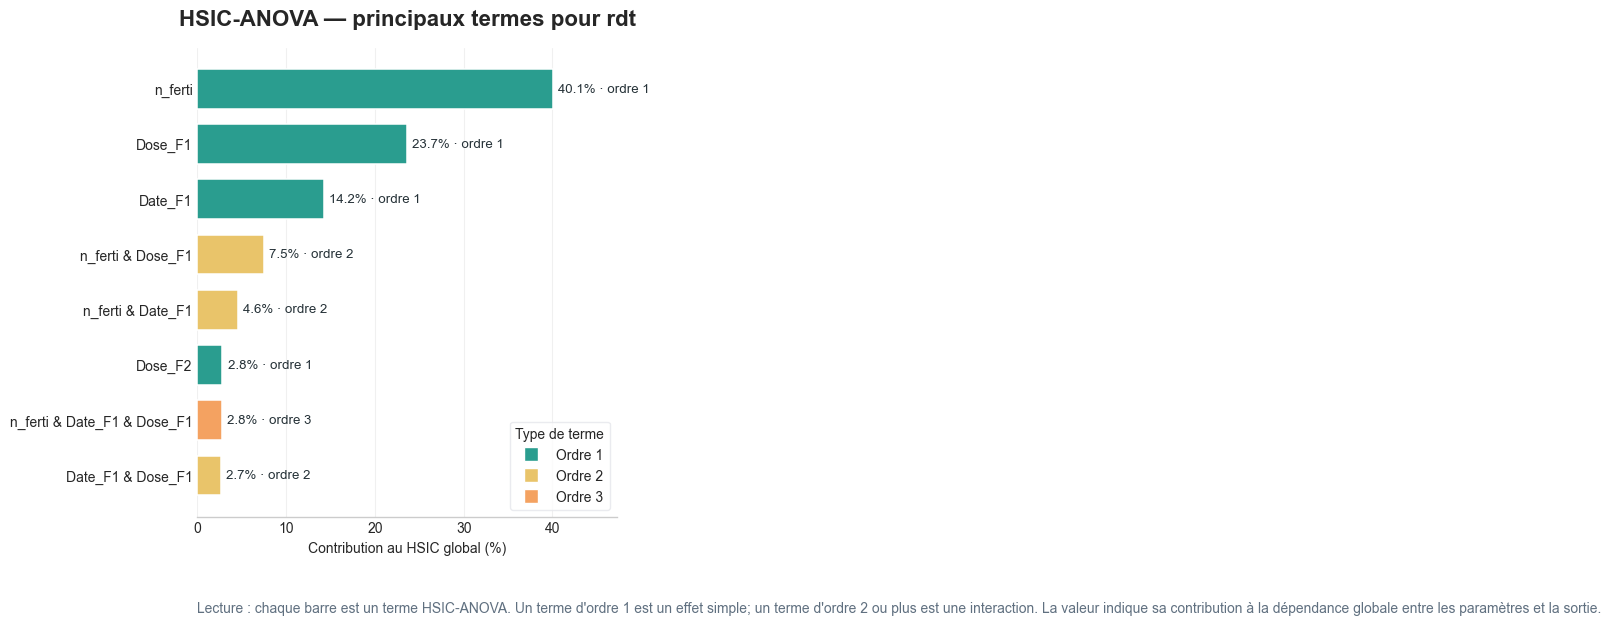

Figure sauvegardée : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_decomposition/hsic_anova_top_terms_rdt.png
Table sauvegardée : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_decomposition/hsic_anova_top_terms_rdt.csv


,sortie,order,variables,global_var_pct
4,N_lixi,1,n_ferti,19.77
1,N_lixi,1,Dose_F2,15.59
5,N_lixi,1,Date_F1,10.33
6,N_lixi,1,Dose_F1,8.91
3,N_lixi,1,Date_F2,7.47
0,N_lixi,1,Dose_F3,5.49
8,N_lixi,2,n_ferti & Date_F1,4.66
15,N_lixi,2,n_ferti & Dose_F1,3.21
16,N_lixi,2,Date_F1 & Dose_F1,2.74
18,N_lixi,3,n_ferti & Date_F1 & Dose_F1,2.37


In [54]:
# =============================================================================
# HSIC-ANOVA — principaux paramètres et interactions par sortie
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

HSIC_TERMS_CSV = OUTPUT_DIR / "hsic_anova_terms_real_maelia.csv"
FIG_DIR = OUTPUT_DIR / "hsic_anova_decomposition"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if "hsic_all" in globals() and not hsic_all.empty:
    hsic_terms = hsic_all.copy()
else:
    hsic_terms = pd.read_csv(HSIC_TERMS_CSV)

if hsic_terms.empty:
    raise ValueError("Aucun terme HSIC-ANOVA disponible. Exécuter d'abord la cellule de calcul HSIC.")

# Harmonisation au cas où le notebook aurait déjà renommé certaines colonnes.
if "global_var_pct" not in hsic_terms.columns and "contribution_hsic_globale_pct" in hsic_terms.columns:
    hsic_terms = hsic_terms.rename(columns={"contribution_hsic_globale_pct": "global_var_pct"})

if "variables" not in hsic_terms.columns and "name" in hsic_terms.columns:
    hsic_terms["variables"] = hsic_terms["name"]

required_cols = {"sortie", "order", "variables", "global_var_pct"}
missing = required_cols - set(hsic_terms.columns)
if missing:
    raise ValueError(f"Colonnes HSIC manquantes : {missing}")

sorties = [s for s in OUTPUT_COLS if s in set(hsic_terms["sortie"])]
if not sorties:
    sorties = list(hsic_terms["sortie"].dropna().unique())

TOP_N = 12

palette = {
    1: "#2A9D8F",
    2: "#E9C46A",
    3: "#F4A261",
    4: "#E76F51",
}

plt.style.use("seaborn-v0_8-whitegrid")

def wrap_label(value, width=34):
    return "\n".join(textwrap.wrap(str(value), width=width, break_long_words=False))

for sortie in sorties:
    data = (
        hsic_terms
        .query("sortie == @sortie")
        .copy()
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["global_var_pct"])
        .sort_values("global_var_pct", ascending=False)
        .head(TOP_N)
    )

    if data.empty:
        print(f"Aucun terme HSIC exploitable pour {sortie}.")
        continue

    data["order"] = data["order"].astype(int)
    data["label"] = data["variables"].map(wrap_label)
    data = data.sort_values("global_var_pct", ascending=True)

    colors = data["order"].map(lambda order: palette.get(order, "#7C8DA6"))

    fig_height = max(5.2, 0.55 * len(data) + 2.0)
    fig, ax = plt.subplots(figsize=(11.5, fig_height))

    bars = ax.barh(
        data["label"],
        data["global_var_pct"],
        color=colors,
        edgecolor="white",
        linewidth=1.1,
        height=0.72,
    )

    xmax = max(1.0, float(data["global_var_pct"].max()) * 1.18)
    ax.set_xlim(0, xmax)

    for bar, value, order in zip(bars, data["global_var_pct"], data["order"]):
        ax.text(
            bar.get_width() + xmax * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}% · ordre {order}",
            va="center",
            ha="left",
            fontsize=9.5,
            color="#263238",
        )

    ax.set_title(
        f"HSIC-ANOVA — principaux termes pour {sortie}",
        fontsize=16,
        fontweight="bold",
        pad=16,
    )
    ax.set_xlabel("Contribution au HSIC global (%)")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.28)
    ax.grid(axis="y", visible=False)

    # Légende par ordre effectivement présent.
    present_orders = sorted(data["order"].unique())
    handles = [
        plt.Line2D(
            [0], [0],
            marker="s",
            linestyle="",
            markersize=10,
            markerfacecolor=palette.get(order, "#7C8DA6"),
            markeredgecolor="white",
            label=f"Ordre {order}",
        )
        for order in present_orders
    ]
    ax.legend(
        handles=handles,
        title="Type de terme",
        loc="lower right",
        frameon=True,
        facecolor="white",
        edgecolor="#E5E7EB",
    )

    ax.text(
        0.0,
        -0.18,
        "Lecture : chaque barre est un terme HSIC-ANOVA. "
        "Un terme d'ordre 1 est un effet simple; un terme d'ordre 2 ou plus est une interaction. "
        "La valeur indique sa contribution à la dépendance globale entre les paramètres et la sortie.",
        transform=ax.transAxes,
        fontsize=10,
        color="#607080",
        va="top",
    )

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()

    fig_path = FIG_DIR / f"hsic_anova_top_terms_{sortie}.png"
    fig.savefig(fig_path, dpi=240, bbox_inches="tight")
    plt.show()

    table_path = FIG_DIR / f"hsic_anova_top_terms_{sortie}.csv"
    data.sort_values("global_var_pct", ascending=False).to_csv(table_path, index=False)

    print(f"Figure sauvegardée : {fig_path}")
    print(f"Table sauvegardée : {table_path}")

display(
    hsic_terms
    .sort_values(["sortie", "global_var_pct"], ascending=[True, False])
    .groupby("sortie")
    .head(TOP_N)
    [["sortie", "order", "variables", "global_var_pct"]]
    .round({"global_var_pct": 2})
)